# Introduction / Theory

### Fast Fourier Transform

- efficient divide and conquer algorithm that computes the Discrete Fourier Transform

- the standard Fourier transform is used to analyze non-periodic functions by taking the limit of the spatial bounds to infinity, which shifts the representation from discrete Fourier series coefficients to a continuos spectrum

- calculating the Discrete Fourier Transform directly on a computer for a data array of size N is computationally expensive having the $O(N^2)$ complexity

- the algorithm originates from the Cooley-Tukey algorithm and we can use it to reduce the complexity from $O(N^2)$ to $O(N \log_{2}{N})$


### How does the algorithm processes data?

- $\textbf{Prime Factorization Dependency}$: efficiency lie within the prime factorization of the array N, so the algorithm is optimzed for cases when $N = 2^p$

- $\textbf{Bit-Reversed Ordering}$: the algorithm begins by reordering teh data vector using a bit reversal scheme

- $\textbf{Recursive Combination}$: when the data is reordered, the Cooley-Tukey algorithm computes the transform by combining neighboring pairs into two point transformations, then recursively merge these into four transformations continuing until until the array is transformed


### Transition from Discrete Fourier Transform to Fast Fourier Transform

- when analyzing computational signals, measurements are typically recorded at discrete time or spatial points, requiring the use of the Discrete Fourier Transform

- while the DFT perfectly maps discrete data points to discrete frequencies, it is highly computationally expensive. Calculating the DFT directly requires a CPU time that scales with $O(N^2)$

- the Fast Fourier Transform fundamentally resolves this bottleneck using the Cooley-Tukey algorithm

- instead of performing the full matrix multiplication, the FFT utilizes bit-reversed ordering to re-index the data array. By reordering the data, the algorithm can recursively combine neighboring pairs into two-point transformations, and subsequently into four-point transformations. This recursive, divide-and-conquer pairing reduces the number of required combinations to $\log_{2}N$ ,shrinking the overall computational complexity to $O(N\log_{2}N)$

### Modulated Gaussian Pulse

- task signal to analyze, translate, differentiate: $f(x) = exp(\frac{-x^2}{2σ^2}) cos(k_0 x)$

- we can split it in two, the first part until the cos is the Gaussian envelope which dictates the shape and the spread of the pulse where σ defines the width of the envelope, the second part (cos) creates the internal oscillations within the envelope where k is the carrier of the wavenumber 

- a Fourier transforms of a Gaussian function is mathematically another Gaussian function

- 1D Wave Packet In physics, the modulated Gaussian pulse described above represents a 1D wave packet—a localized disturbance or "burst" of wave energy that travels through space. You will be analyzing this wavepacket over a specific one-dimensional spatial domain, such as x∈[−10,10]. The concept of a wave packet has profound implications in quantum mechanics (QM). Because the Fourier transform connects the wave's spatial coordinates (position) with its wavenumbers (momentum), the width of the wave packet in real space is inversely proportional to its width in momentum space

### Spectral Differenctiation and Boundary Conditions

- powerful application of the Fourier transform is its ability to diagonalize the derivative operator. Taking the derivative of a function in real space strictly corresponds to multiplying its Fourier transform by $i\omega$ (or $ik$ in spatial terms):

$$\mathfrak{F}[f^{\prime}(t)]=i\omega\tilde{f}(\omega)$$

- because this operation is performed in the frequency domain, it is highly accurate and avoids the truncation errors inherent to local finite difference methods

- however, for this Fourier property to hold mathematically, the function $f(t)$ must vanish as $t\rightarrow\pm\infty$, since otherwise the Fourier transform simply does not exist

- Gaussian envelope decays exponentially to zero as $|x|$ increases, it perfectly satisfies this strict boundary condition, making spectral differentiation highly suitable


# Numerical Methods

- Fast Fourier Transform: highly optimized, recursive $O(N\log_{2}N)$ numerical algorithm used to rapidly compute the Discrete Fourier Transform and its inverse, acting as the primary engine for analyzing the signal's spectral components

- Spectral Differentiation: numerical method that computes highly precise derivatives by transforming the entire spatial dataset into frequency space, applying the analytical operator $ik$, and transforming the result back to real space

- Finite Difference Method: numerical approximation technique used to establish a baseline for comparison. It computes the derivative by taking the difference between adjacent discrete spatial points divided by the spatial step size $\Delta x$

- Spectral Translation: numerical technique that exploits the mathematical Shift Theorem to perfectly translate a discretized signal across a grid by applying a complex phase shift in momentum space, completely bypassing spatial interpolation


#### The Shannon-Nyquist sampling theorem

- this theorem applies to both Discrete Fourier Transforms and Fast Fourier Transforms

- the theorem states that if we have an analogous signal with a period of $\Delta$, the complete course of the signal can only be constructed if the largest frequency present in the signal is smaller than half of the sampling rate which is $\frac{1}{\Delta}$

- the signal frequencies must fall within the following range $\frac{-1}{2 \Delta}$ to $\frac{1}{2 \Delta}$

- in the context of the given spatial step size $\Delta x$ upper limit defines your Nyquist wavenumber as $k_{N_{yquist}} = \frac{\pi}{\Delta x}$

- When you compute the FFT on the grid (N=40), the spatial step size is large, meaning the Nyquist limit drops. If the actual physical frequencies of your Gaussian wavepacket exceed this limit, the frequencies fold back into the measurement range incorrectly

- as noted in the lecture theory, this phenomenon is called an "aliased" Fourier Transform, which explains why the coarse grid fails to represent the true physical frequencies of the wavepacket

Coarse Grid Nyquist Limit: 6.1261056745000975
Fine Grid Nyquist Limit: 80.26769229921922


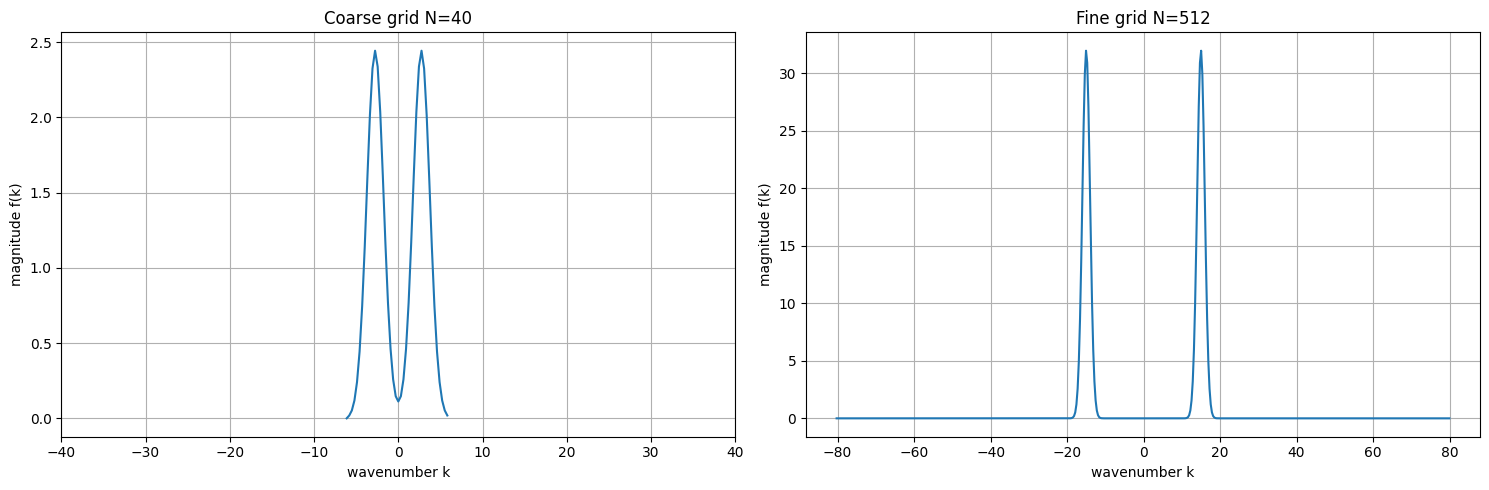

In [ ]:
#code for a)

import numpy as np
import matplotlib.pyplot as plt
import math

standard_deviation_envelope = 1.0
carrier_wave_number = 15.0
x_min = -10.0
x_max = 10.0

x_coarse_grid = np.linspace(x_min, x_max, 40, endpoint= True)
x_fine_grid = np.linspace(x_min, x_max, 512, endpoint=True)


physical_distance_coarse_grid = (x_max - x_min) / (40 - 1) 
physical_distance_fine_grid = (x_max - x_min) / (512 - 1)

k_nyquist_coarse_grid = np.pi / physical_distance_coarse_grid
k_nyquist_fine_grid = np.pi / physical_distance_fine_grid

function_x_coarse_grid = np.exp(-((x_coarse_grid**2) / (2*standard_deviation_envelope**2))) * np.cos(carrier_wave_number * x_coarse_grid)
function_x_fine_grid = np.exp(-((x_fine_grid**2) / (2*standard_deviation_envelope**2))) * np.cos(carrier_wave_number * x_fine_grid)


fft_coarse_grid = np.fft.fft(function_x_coarse_grid)
fft_fine_grid = np.fft.fft(function_x_fine_grid)

wavenumber_array_coarse_grid = np.fft.fftfreq(40, physical_distance_coarse_grid) * 2 * np.pi
wavenumber_array_fine_grid = np.fft.fftfreq(512, physical_distance_fine_grid) * 2 * np.pi

fft_coarse_grid_shifted = np.fft.fftshift(fft_coarse_grid)
fft_fine_grid_shifted = np.fft.fftshift(fft_fine_grid)

wavenumber_array_coarse_grid_shifted = np.fft.fftshift(wavenumber_array_coarse_grid)
wavenumber_array_fine_grid_shifted = np.fft.fftshift(wavenumber_array_fine_grid)

magnitude_coarse_grid = np.abs(fft_coarse_grid_shifted)
magnitude_fine_grid = np.abs(fft_fine_grid_shifted)

print(f"Coarse Grid Nyquist Limit: {k_nyquist_coarse_grid}")
print(f"Fine Grid Nyquist Limit: {k_nyquist_fine_grid}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(wavenumber_array_coarse_grid_shifted, magnitude_coarse_grid)
ax1.set_title("Coarse grid N=40")
ax1.set_xlabel("wavenumber k")
ax1.set_ylabel("magnitude f(k)")
ax1.set_xlim([-40.0, 40.0])
ax1.grid()

ax2.plot(wavenumber_array_fine_grid_shifted, magnitude_fine_grid)
ax2.set_title("Fine grid N=512")
ax2.set_xlabel("wavenumber k")
ax2.set_ylabel("magnitude f(k)")
ax1.set_xlim([-40.0, 40.0])
ax2.grid()

plt.tight_layout()
plt.show()


#### The Shift Theorem (Spectral Translation)

- translating a discretized signal in real space by a distance that is not an exact integer multiple of the discrete step size ($\Delta x$) traditionally requires complex polynomial interpolation

- the Fourier Shift Theorem offers an exact analytical alternative

- according to the shift relation, a spatial translation by a distance $t_0$ corresponds precisely to multiplying the frequency domain by a complex linear phase factor:

$$\mathfrak{F}[f(t-t_{0})]=e^{-i\omega t_{0}}\tilde{f}(\omega)$$

- computing the FFT of the unshifted wavepacket, multiplying the resulting array by this phase factor, and applying the Inverse Fast Fourier Transform , the wavepacket is translated perfectly across the computational grid without any loss of resolution or shape distortion

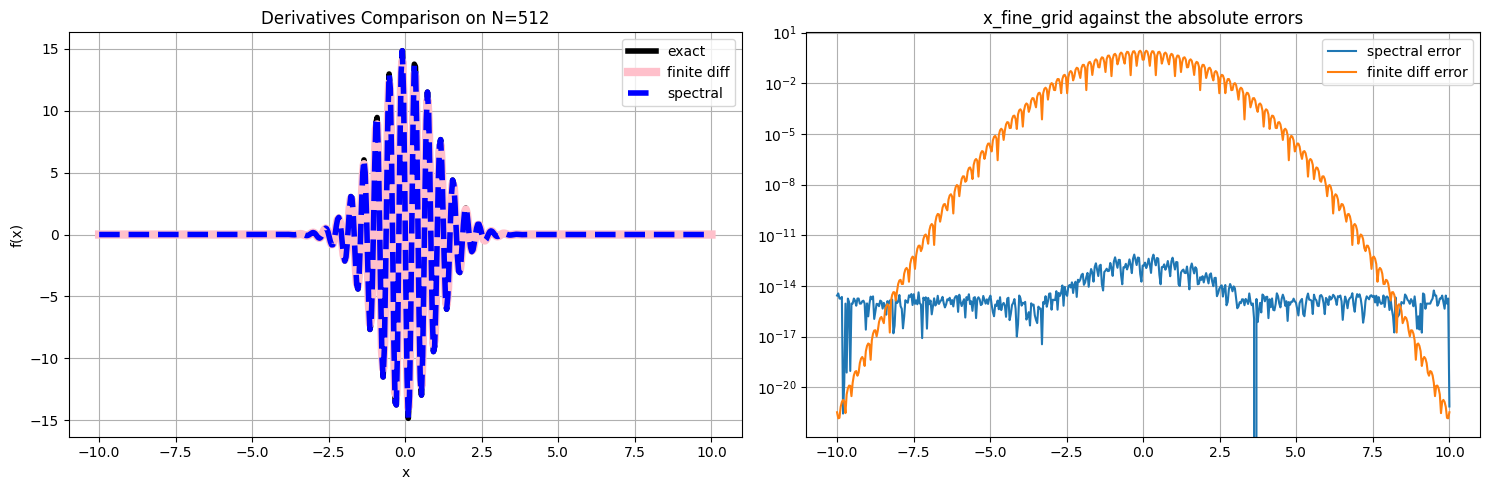

In [19]:
#code for b)

import numpy as np
import matplotlib.pyplot as plt

standard_deviation_envelope = 1.0
carrier_wave_number = 15.0
x_min = -10.0
x_max = 10.0
z = 1j

def function(x):
    function = np.exp(-((x**2) / (2*standard_deviation_envelope**2))) * np.cos(carrier_wave_number * x)
    return function

x_fine_grid = np.linspace(x_min, x_max, 512, endpoint=True)

physical_distance_fine_grid = (x_max - x_min) / (512 - 1)

function_x_fine_grid = np.exp(-((x_fine_grid**2) / (2*standard_deviation_envelope**2))) * np.cos(carrier_wave_number * x_fine_grid)

f_derivative_exact = (-((x_fine_grid)/(standard_deviation_envelope**2))) * function_x_fine_grid - carrier_wave_number * np.exp(-((x_fine_grid**2)/(2*standard_deviation_envelope**2))) * np.sin(carrier_wave_number * x_fine_grid)

fx_jplus1 = np.roll(function_x_fine_grid, -1)
fx_jminus1 = np.roll(function_x_fine_grid, 1)

derivative_finite_diff = (fx_jplus1 - fx_jminus1) / (2 * physical_distance_fine_grid)

fft_fine_grid = np.fft.fft(function_x_fine_grid)
wavenumber_array_fine_grid = np.fft.fftfreq(512, physical_distance_fine_grid) * 2 * np.pi


spectral_derivative_k_space = z * wavenumber_array_fine_grid * fft_fine_grid
spectral_derivative_inverse = np.fft.ifft(spectral_derivative_k_space)
derivative_spectral = np.real(spectral_derivative_inverse)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(x_fine_grid, f_derivative_exact, label ="exact", color="Black", linewidth = 4)
ax1.plot(x_fine_grid, derivative_finite_diff, label="finite diff", color="Pink", linewidth = 6)
ax1.plot(x_fine_grid, derivative_spectral, label="spectral", color="blue", linewidth = 4, linestyle = "--")  
ax1.set_title("Derivatives Comparison on N=512")
ax1.set_xlabel("x")
ax1.set_ylabel("f(x)")
ax1.legend()
ax1.grid()

error1 = np.abs(derivative_spectral - f_derivative_exact)
error2 = np.abs(derivative_finite_diff - f_derivative_exact)
ax2.plot(x_fine_grid, error1, label="spectral error")
ax2.plot(x_fine_grid, error2, label="finite diff error")
ax2.set_title("x_fine_grid against the absolute errors")
ax2.set_yscale('log')
ax2.legend()
ax2.grid()
plt.tight_layout()
plt.show()

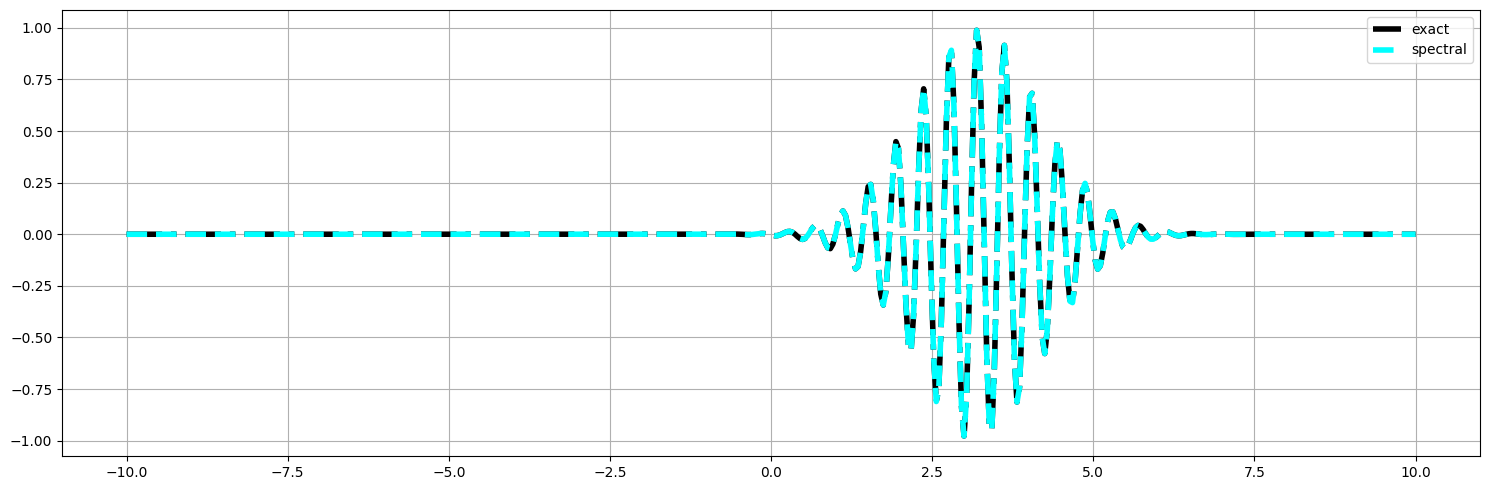

In [23]:
#code for c)

import numpy as np
import matplotlib.pyplot as plt

standard_deviation_envelope = 1.0
carrier_wave_number = 15.0
x_min = -10.0
x_max = 10.0
z = 1j

def function(x):
    function = np.exp(-((x**2) / (2*standard_deviation_envelope**2))) * np.cos(carrier_wave_number * x)
    return function

x_fine_grid = np.linspace(x_min, x_max, 512, endpoint=True)
physical_distance_fine_grid = (x_max - x_min) / (512 - 1)
wavenumber_array_fine_grid = np.fft.fftfreq(512, physical_distance_fine_grid) * 2 * np.pi
fft_fine_grid = np.fft.fft(function(x_fine_grid))

f_exact_shifted = function(x_fine_grid - 3.2)

complex_exponential_shift = np.exp(-z * wavenumber_array_fine_grid * 3.2)

multi = fft_fine_grid * complex_exponential_shift
multi_inversion = np.fft.ifft(multi)
function_spectral_shifted = np.real(multi_inversion)

fig, ax1 = plt.subplots(1, 1, figsize=(15, 5))
ax1.plot(x_fine_grid, f_exact_shifted, label="exact", color = "black", linewidth= 4, linestyle ="-.")
ax1.plot(x_fine_grid, function_spectral_shifted, label="spectral", color="cyan", linewidth = 4, linestyle="--")
ax1.legend()
ax1.grid()
plt.tight_layout()
plt.show()

- spatial domain is exactly 20.0 units wide (from -10.0 to 10.0). If you shift a pulse to the right by 15.0, it pushes past the right boundary. Because the FFT operates entirely on periodic boundary conditions, whatever exits the right side instantly wraps around and re-enters the left side. A positive shift of 15.0 looks exactly the same as a negative shift of 5.0

#### FFT Efficiency and Bit-Reversed Ordering

- theory behind the algorithm's ability to reduce complexity from $O(N^2)$ to $O(N log_2 N)$ relies heavily on bit-reversed ordering

- The FFT speeds up calculations by recursively dividing the data, a process that requires the algorithm to reorder the data vector according to a bit-reversal scheme. For example, if you have 16 data points, the algorithm looks at the binary index: an index of 8 (binary 1000) is reversed to become 1 (binary 0001), and an index of 12 (binary 1100) is reversed to 3 (binary 0011)

- Once reordered, the algorithm combines neighboring pairs into two-point transformations, then merges those into four-point transformations, and continues building up recursively. This highly efficient pairing and dividing strategy specifically demands that the array size N can be continually halved (it relies heavily on the prime factorization being powers of 2). When you attempt to process a prime number of data points ($N_2$=1,000,003), the array cannot be recursively halved into symmetric pairs, effectively breaking the Cooley-Tukey mechanism and forcing the computer to perform calculations much more slowly despite the overall array being smaller



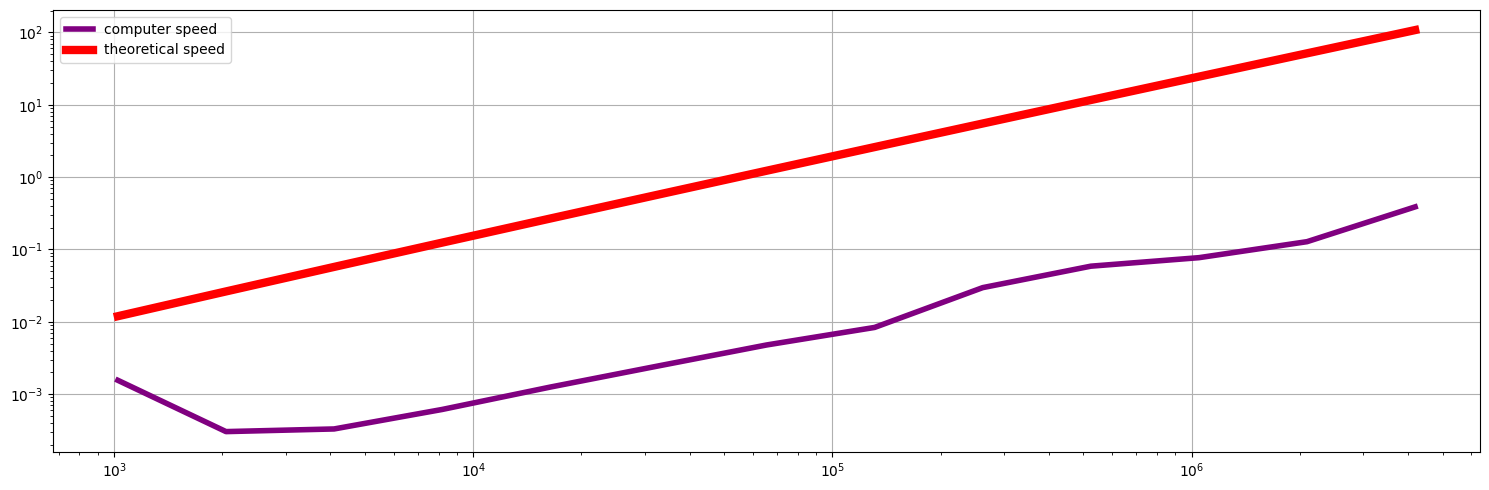

Time for N1 (2^20): 0.05901503562927246 seconds
Time for N2 (1,000,003): 0.30146026611328125 seconds


In [29]:
#code for d)

import numpy as np
import matplotlib.pyplot as plt
import time


N_values = []
T_values = []

for i in range(10, 23):
    N = 2**i
    N_values.append(N)

    random_data = np.random.rand(N)
    start_time = time.time()
    transform = np.fft.fft(random_data)
    end_time = time.time()

    duration = end_time - start_time
    T_values.append(duration)

N_array = np.array(N_values)
T_array = np.array(T_values)

c = T_array[6] / N_array[6] * np.log2(N_array[6])
T_ref = c * N_array * np.log2(N_array)

fig, ax1 = plt.subplots(1, 1, figsize=(15, 5))
ax1.plot(N_array, T_array, label="computer speed", color="purple" ,linewidth =4)
ax1.plot(N_array, T_ref, label="theoretical speed", color="red", linewidth =6)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.legend()
ax1.grid()
plt.tight_layout()
plt.show()

N1 = 2**20
N2 = 1000003

data_N1 = np.random.rand(N1)
start_N1 = time.time()
np.fft.fft(data_N1)
end_N1 = time.time()

data_N2 = np.random.rand(N2)
start_N2 = time.time()
np.fft.fft(data_N2)
end_N2 = time.time()

print(f"Time for N1 (2^20): {end_N1 - start_N1} seconds")
print(f"Time for N2 (1,000,003): {end_N2 - start_N2} seconds")